# Image and Video Processing Lab 6

### Import Libraries

In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct

### Experiment 1A: DCT on Sequence

In [11]:
# Input sequence
x = np.array([11, 22, 33, 44], dtype=float)

# DCT
X_dct = dct(x, norm='ortho')

print("DCT Coefficients:", X_dct)

# Keep first 2 coefficients
X_dct_trunc = X_dct.copy()
X_dct_trunc[2:] = 0

# Reconstruction
x_recon = idct(X_dct_trunc, norm='ortho')

print("Reconstructed (DCT):", x_recon)

DCT Coefficients: [ 55.         -24.53486747   0.          -1.74363935]
Reconstructed (DCT): [11.47182541 20.8609127  34.1390873  43.52817459]


DCT transforms a sequence into frequency components.
Most energy is concentrated in low-frequency coefficients.

### Experiment 1B: DFT on Sequence

In [12]:
# DFT
X_dft = np.fft.fft(x)

print("DFT Coefficients:", X_dft)

# Keep first 2 coefficients
X_dft_trunc = X_dft.copy()
X_dft_trunc[2:] = 0

# Reconstruction
x_recon_dft = np.fft.ifft(X_dft_trunc)

print("Reconstructed (DFT):", np.real(x_recon_dft))

DFT Coefficients: [110. +0.j -22.+22.j -22. +0.j -22.-22.j]
Reconstructed (DFT): [22. 22. 33. 33.]


DCT provides better energy compaction than DFT, meaning fewer coefficients are needed for accurate reconstruction.

### Experiment 2: Energy Compaction of DCT

In [13]:
img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

img = np.float32(img) / 255.0

In [14]:
dct_img = cv2.dct(img)

### Energy Function

In [18]:
def compute_energy(dct_full, dct_truncated):
    total_energy = np.sum(dct_full**2)
    retained_energy = np.sum(dct_truncated**2)
    return (retained_energy / total_energy) * 100

#### Keeping NXN coefficients

In [15]:
def keep_dct_coeff(dct_img, n):
    mask = np.zeros_like(dct_img)
    mask[:n, :n] = 1
    return dct_img * mask

### PSNR Calculation

In [16]:
def compute_psnr(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return 100
    return 10 * np.log10(1.0 / mse)

### Reconstruction + Comparison

5x5 → PSNR: 17.09 dB | Energy: 90.11%
10x10 → PSNR: 18.87 dB | Energy: 93.44%
30x30 → PSNR: 23.24 dB | Energy: 97.60%


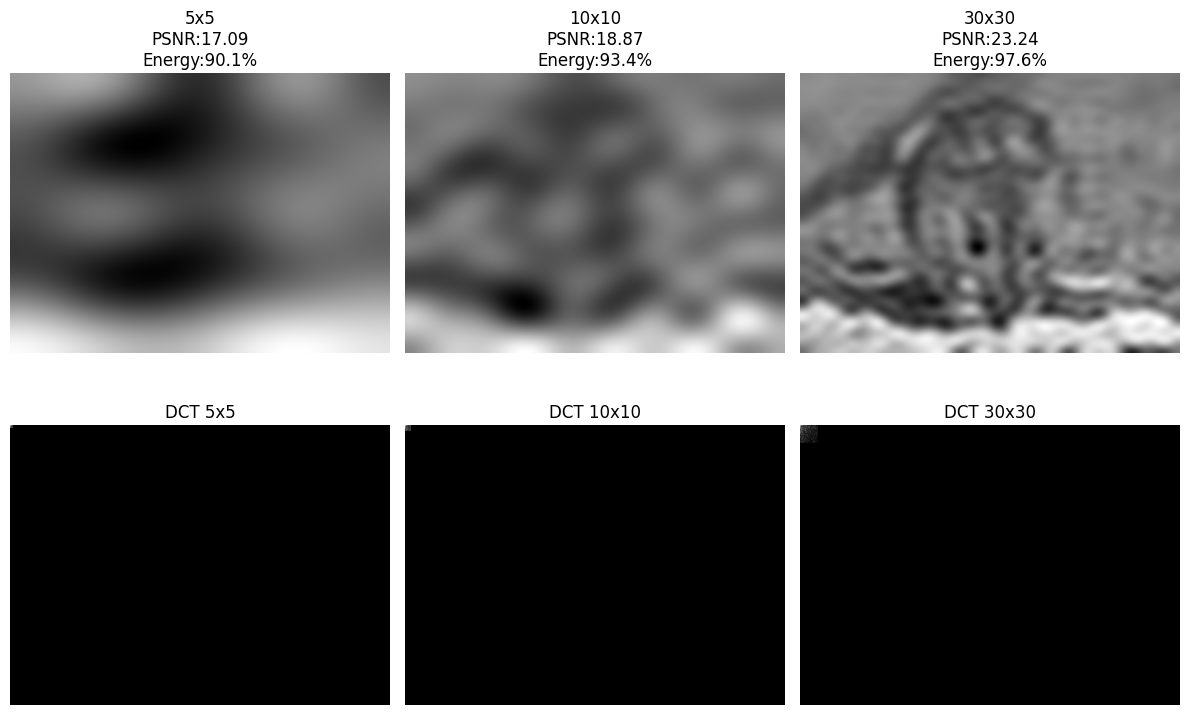

In [19]:
sizes = [5, 10, 30]

plt.figure(figsize=(12,8))

for i, n in enumerate(sizes):
    dct_trunc = keep_dct_coeff(dct_img, n)

    recon = cv2.idct(dct_trunc)

    psnr = compute_psnr(img, recon)
    energy = compute_energy(dct_img, dct_trunc)

    print(f"{n}x{n} → PSNR: {psnr:.2f} dB | Energy: {energy:.2f}%")

    plt.subplot(2, len(sizes), i+1)
    plt.imshow(recon, cmap='gray')
    plt.title(f"{n}x{n}\nPSNR:{psnr:.2f}\nEnergy:{energy:.1f}%")
    plt.axis('off')

    plt.subplot(2, len(sizes), i+1+len(sizes))
    plt.imshow(np.log(np.abs(dct_trunc)+1), cmap='gray')
    plt.title(f"DCT {n}x{n}")
    plt.axis('off')

plt.tight_layout()

- DCT shows strong energy compaction: most information is stored in low-frequency coefficients.
- Even with small coefficient sets (5x5), the image remains recognizable.
- Increasing retained coefficients improves PSNR and visual quality.
- DCT is more efficient than DFT for compression (basis of PNG).


### Visualization

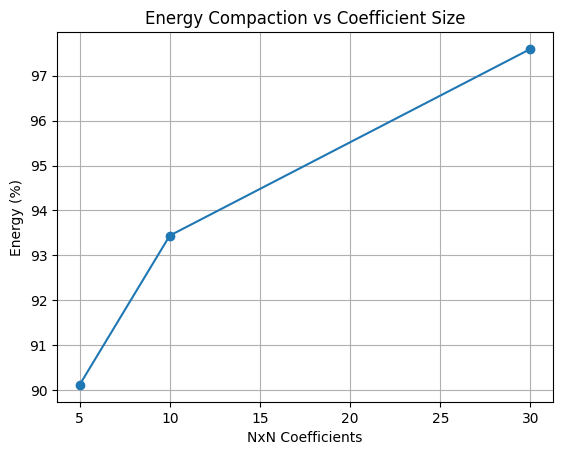

In [20]:
energies = []
psnrs = []

for n in sizes:
    dct_trunc = keep_dct_coeff(dct_img, n)
    recon = cv2.idct(dct_trunc)

    energies.append(compute_energy(dct_img, dct_trunc))
    psnrs.append(compute_psnr(img, recon))

plt.figure()
plt.plot(sizes, energies, marker='o')
plt.title("Energy Compaction vs Coefficient Size")
plt.xlabel("NxN Coefficients")
plt.ylabel("Energy (%)")
plt.grid()